In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import time

class GridWorld:
    def __init__(self):
        # Create the grid based on the image
        # 0 = Frozen (white), 1 = Hole (gray), 2 = Start (red), 3 = Terminal (green)
        self.grid = np.array([
            [2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0],
        ])
        
        self.rows, self.cols = self.grid.shape
        self.start_pos = np.where(self.grid == 2)
        self.start_pos = (self.start_pos[0][0], self.start_pos[1][0])
        self.terminal_pos = np.where(self.grid == 3)
        self.terminal_pos = (self.terminal_pos[0][0], self.terminal_pos[1][0])
        
        # Actions: 0=Right, 1=Left, 2=Up, 3=Down
        self.actions = ['Right', 'Left', 'Up', 'Down']
        self.action_moves = [(0, 1), (0, -1), (-1, 0), (1, 0)]
        
        self.reset()
    
    def reset(self):
        self.agent_pos = self.start_pos
        return self.get_state()
    
    def get_state(self):
        return self.agent_pos[0] * self.cols + self.agent_pos[1]
    
    def step(self, action):
        row, col = self.agent_pos
        d_row, d_col = self.action_moves[action]
        new_row, new_col = row + d_row, col + d_col
        
        # Check boundaries
        if new_row < 0 or new_row >= self.rows or new_col < 0 or new_col >= self.cols:
            # Stay in place if hitting boundary
            reward = -1
            done = False
        else:
            # Move to new position
            self.agent_pos = (new_row, new_col)
            cell_type = self.grid[new_row, new_col]
            
            if cell_type == 1:  # Hole
                reward = -100
                done = True
            elif cell_type == 3:  # Terminal
                reward = 100
                done = True
            else:  # Frozen
                reward = -1
                done = False
        
        return self.get_state(), reward, done



In [2]:
class QLearningAgent:
    def __init__(self, state_size, action_size, learning_rate=0.1, discount_factor=0.95, epsilon=1.0):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        
        # Initialize Q-table
        self.q_table = np.zeros((state_size, action_size))
    
    def get_action(self, state):
        # Epsilon-greedy action selection
        if random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)
        else:
            return np.argmax(self.q_table[state])
    
    def update_q_table(self, state, action, reward, next_state, done):
        if done:
            target = reward
        else:
            target = reward + self.discount_factor * np.max(self.q_table[next_state])
        
        self.q_table[state, action] += self.learning_rate * (target - self.q_table[state, action])
    
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay



In [ ]:
def train_agent(episodes=1000):
    env = GridWorld()
    agent = QLearningAgent(env.rows * env.cols, len(env.actions))
    
    rewards = []
    success_count = 0
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0
        max_steps = 200
        
        while steps < max_steps:
            action = agent.get_action(state)
            next_state, reward, done = env.step(action)
            agent.update_q_table(state, action, reward, next_state, done)
            
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                if reward == 100:  # Reached terminal
                    success_count += 1
                break
        
        agent.decay_epsilon()
        rewards.append(total_reward)
        
        if episode % 100 == 0:
            success_rate = success_count / (episode + 1) * 100
            print(f"Episode {episode}, Success Rate: {success_rate:.2f}%, Epsilon: {agent.epsilon:.3f}")
    
    return env, agent, rewards

In [21]:
def visualize_policy(env, agent):
    policy = np.zeros((env.rows, env.cols), dtype=int)
    
    for row in range(env.rows):
        for col in range(env.cols):
            if env.grid[row, col] == 1:  # Hole
                policy[row, col] = -1
            elif env.grid[row, col] == 3:  # Terminal
                policy[row, col] = -2
            else:
                state = row * env.cols + col
                policy[row, col] = np.argmax(agent.q_table[state])
    
    return policy

def test_trained_agent(env, agent, visualize=True):
    state = env.reset()
    path = [env.agent_pos]
    actions_taken = []
    total_reward = 0
    steps = 0
    max_steps = 100
    
    print("Testing trained agent...")
    print(f"Start position: {env.agent_pos}")
    
    while steps < max_steps:
        action = np.argmax(agent.q_table[state])  # Use best action (no exploration)
        next_state, reward, done = env.step(action)
        
        path.append(env.agent_pos)
        actions_taken.append(env.actions[action])
        total_reward += reward
        steps += 1
        
        if visualize:
            print(f"Step {steps}: Action={env.actions[action]}, Position={env.agent_pos}, Reward={reward}")
        
        if done:
            if reward == 100:
                print(f"SUCCESS! Reached terminal in {steps} steps with total reward: {total_reward}")
            else:
                print(f"FAILED! Fell into hole at {env.agent_pos}")
            break
        
        state = next_state
    
    if steps >= max_steps:
        print("Max steps reached without reaching terminal")
    
    return path, actions_taken, total_reward

def plot_results(rewards, env, agent):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot training rewards
    ax1.plot(rewards)
    ax1.set_title('Training Rewards Over Episodes')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.grid(True)
    
    # Plot success rate (moving average)
    window_size = 100
    success_rewards = [1 if r > 0 else 0 for r in rewards]
    moving_avg = np.convolve(success_rewards, np.ones(window_size)/window_size, mode='valid')
    ax2.plot(moving_avg)
    ax2.set_title(f'Success Rate (Moving Average, Window={window_size})')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Success Rate')
    ax2.grid(True)
    
    # Visualize grid
    colors = ['white', 'gray', 'red', 'green']
    cmap = ListedColormap(colors)
    ax3.imshow(env.grid, cmap=cmap, vmin=0, vmax=3)
    ax3.set_title('Grid World')
    ax3.set_xticks([])
    ax3.set_yticks([])
    
    # Add grid lines
    for i in range(env.rows + 1):
        ax3.axhline(i - 0.5, color='black', linewidth=0.5)
    for i in range(env.cols + 1):
        ax3.axvline(i - 0.5, color='black', linewidth=0.5)
    
    # Visualize policy
    policy = visualize_policy(env, agent)
    policy_display = np.copy(env.grid).astype(float)
    
    # Create arrow visualization
    arrow_chars = ['→', '←', '↑', '↓']
    for row in range(env.rows):
        for col in range(env.cols):
            if env.grid[row, col] == 0:  # Only show arrows for frozen cells
                action = policy[row, col]
                ax4.text(col, row, arrow_chars[action], ha='center', va='center', fontsize=8)
    
    ax4.imshow(env.grid, cmap=cmap, vmin=0, vmax=3, alpha=0.7)
    ax4.set_title('Learned Policy (Arrows show best action)')
    ax4.set_xticks([])
    ax4.set_yticks([])
    
    # Add grid lines
    for i in range(env.rows + 1):
        ax4.axhline(i - 0.5, color='black', linewidth=0.5)
    for i in range(env.cols + 1):
        ax4.axvline(i - 0.5, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()


Training Q-learning agent...
Episode 0, Success Rate: 0.00%, Epsilon: 0.995
Episode 100, Success Rate: 0.00%, Epsilon: 0.603
Episode 200, Success Rate: 0.00%, Epsilon: 0.365
Episode 300, Success Rate: 0.00%, Epsilon: 0.221
Episode 400, Success Rate: 0.25%, Epsilon: 0.134
Episode 500, Success Rate: 0.80%, Epsilon: 0.081
Episode 600, Success Rate: 3.83%, Epsilon: 0.049
Episode 700, Success Rate: 9.42%, Epsilon: 0.030
Episode 800, Success Rate: 15.86%, Epsilon: 0.018
Episode 900, Success Rate: 22.97%, Epsilon: 0.011

Training completed!

Sample Q-values for key states:
State		Right	Left	Up	Down
---------------------------------------------
Start		-12.1	-12.1	-12.1	-12.0
(0,5)		-9.4	-9.4	-9.4	-9.4
(0,10)		-7.5	-7.6	-7.5	-7.6
(0,15)		-5.8	-5.8	-5.8	-5.8
(0,20)		-4.4	-4.4	-4.4	-4.4
(3,0)		-19.0	-3.9	-10.0	-3.9
(3,10)		-7.0	-7.0	-7.0	-7.0
(3,15)		-5.4	-5.4	-5.4	-5.4
(3,20)		-4.0	-4.0	-4.0	-4.0
(6,0)		-4.0	-4.0	-4.0	-4.0
(6,5)		-4.4	-4.3	-27.1	-4.3
(6,10)		-5.6	-5.6	-5.7	-5.6
(6,15)		-4.3	-4.4

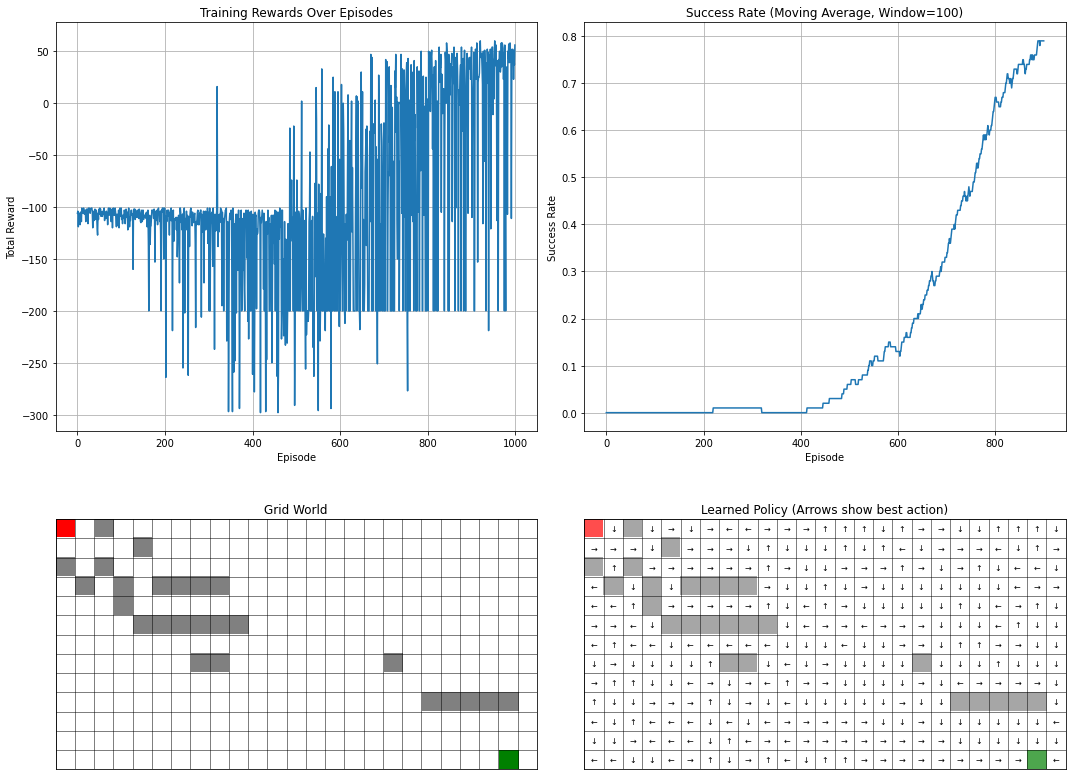

In [22]:
def print_q_table_sample(agent, env):
    print("\nSample Q-values for key states:")
    print("State\t\tRight\tLeft\tUp\tDown")
    print("-" * 45)
    
    # Show Q-values for start state
    start_state = env.start_pos[0] * env.cols + env.start_pos[1]
    print(f"Start\t\t{agent.q_table[start_state, 0]:.1f}\t{agent.q_table[start_state, 1]:.1f}\t{agent.q_table[start_state, 2]:.1f}\t{agent.q_table[start_state, 3]:.1f}")
    
    # Show Q-values for some other states
    for row in range(0, env.rows, 3):
        for col in range(0, env.cols, 5):
            if env.grid[row, col] == 0:  # Only frozen cells
                state = row * env.cols + col
                print(f"({row},{col})\t\t{agent.q_table[state, 0]:.1f}\t{agent.q_table[state, 1]:.1f}\t{agent.q_table[state, 2]:.1f}\t{agent.q_table[state, 3]:.1f}")

if __name__ == "__main__":
    print("Training Q-learning agent...")
    env, agent, rewards = train_agent(episodes=1000)
    
    print("\nTraining completed!")
    print_q_table_sample(agent, env)
    
    print("\n" + "="*50)
    path, actions, total_reward = test_trained_agent(env, agent)
    
    print(f"\nPath taken: {path}")
    print(f"Actions: {actions}")
    
    # Plot results
    plot_results(rewards, env, agent)